In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
titanic = sns.load_dataset("titanic")

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
# let select some feature and work on it
feature = ["pclass", "sex", "fare", "embarked","age"]
target = ["survived"]

In [11]:
# import the imputer to fill the missing values
from sklearn.impute import SimpleImputer

In [18]:
# remove all null using imputer and replace with mean  median ,mode

# numerical data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# categorical data
imp_freq1 = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq1.fit_transform(titanic[["embarked"]])

# categorical data
imp_freq2 = SimpleImputer(strategy="most_frequent")
titanic[["embark_town"]] = imp_freq2.fit_transform(titanic[["embark_town"]])

# categorical data
imp_freq3 = SimpleImputer(strategy="most_frequent")
titanic[["deck"]] = imp_freq3.fit_transform(titanic[["deck"]])


In [19]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [21]:
# now we do level encoder
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [32]:
titanic.head(300)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,C,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,C,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,1,1,28.0,0,0,27.7208,0,First,man,True,C,Cherbourg,no,True
296,0,3,1,23.5,0,0,7.2292,0,Third,man,True,C,Cherbourg,no,True
297,0,1,0,2.0,1,2,151.5500,2,First,child,False,C,Southampton,no,False
298,1,1,1,28.0,0,0,30.5000,2,First,man,True,C,Southampton,yes,True


In [33]:
# split features
X = titanic[feature]
y = titanic[target]

In [35]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [36]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size = 0.2 ,random_state = 42
)

In [38]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [40]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [41]:
# decision tree model - no pruning
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\naccuracy_score:\n", accuracy_score(y_test, y_pred))

F1 score: 0.7272727272727273

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       105
           1       0.70      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179


Confusion Matrix:
 [[81 24]
 [18 56]]

accuracy_score:
 0.7653631284916201


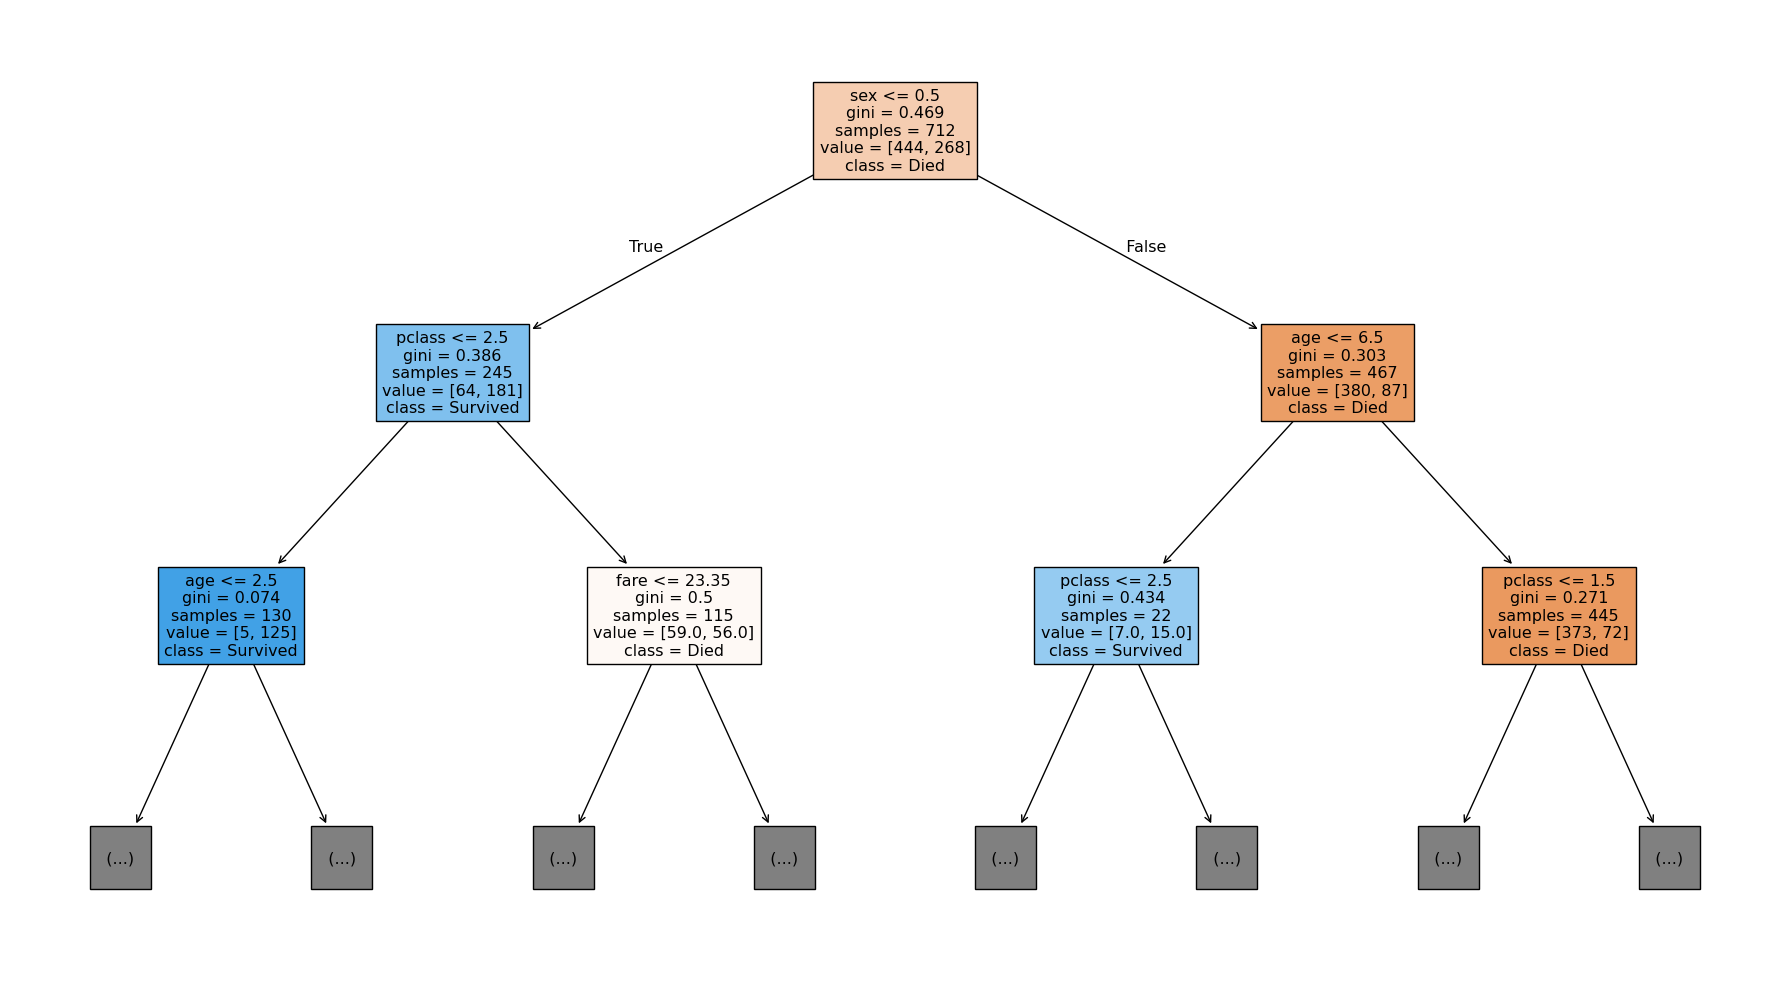

In [64]:
# plot eecision tree
from sklearn.tree import plot_tree

plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 2
)

plt.tight_layout()
plt.show()
